<a href="https://colab.research.google.com/github/I7411/THDeepLearning/blob/main/CNN_Buoi3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import tensorflow as tf
import keras
from keras.layers import Conv2D, Dense, MaxPool2D, Flatten
from keras.models import Sequential
from keras import Input
#data visualization packages
import matplotlib.pyplot as plt

In [2]:
import pandas as pd
import numpy as np

# Đường dẫn dữ liệu MNIST có sẵn trong Google Colab
mnist_train = "/content/sample_data/mnist_train_small.csv"
mnist_test = "/content/sample_data/mnist_test.csv"

# Đọc dữ liệu
# header=None để không làm mất dòng đầu tiên
df_train = pd.read_csv(mnist_train, header=None)
df_test = pd.read_csv(mnist_test, header=None)

print("Train dataframe:", df_train.shape)
print("Test dataframe:", df_test.shape)

# Cột 0 là nhãn, các cột còn lại là pixel
X_train = df_train.iloc[:, 1:].values
y_train = df_train.iloc[:, 0].values

X_test = df_test.iloc[:, 1:].values
y_test = df_test.iloc[:, 0].values

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

Train dataframe: (20000, 785)
Test dataframe: (10000, 785)
X_train: (20000, 784)
y_train: (20000,)
X_test: (10000, 784)
y_test: (10000,)


In [3]:
num_classes = 10
input_shape = (28, 28, 1)

# Chuẩn hóa pixel về [0, 1]
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

# Reshape từ vector 784 thành ảnh 28x28x1
X_train = X_train.reshape(X_train.shape[0], 28, 28, 1)
X_test = X_test.reshape(X_test.shape[0], 28, 28, 1)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

print("Number of classes:", len(np.unique(y_train)))
print("Classes:", np.unique(y_train))
print("First 5 labels:", y_train[:5])

X_train: (20000, 28, 28, 1)
X_test: (10000, 28, 28, 1)
Number of classes: 10
Classes: [0 1 2 3 4 5 6 7 8 9]
First 5 labels: [6 5 7 9 5]


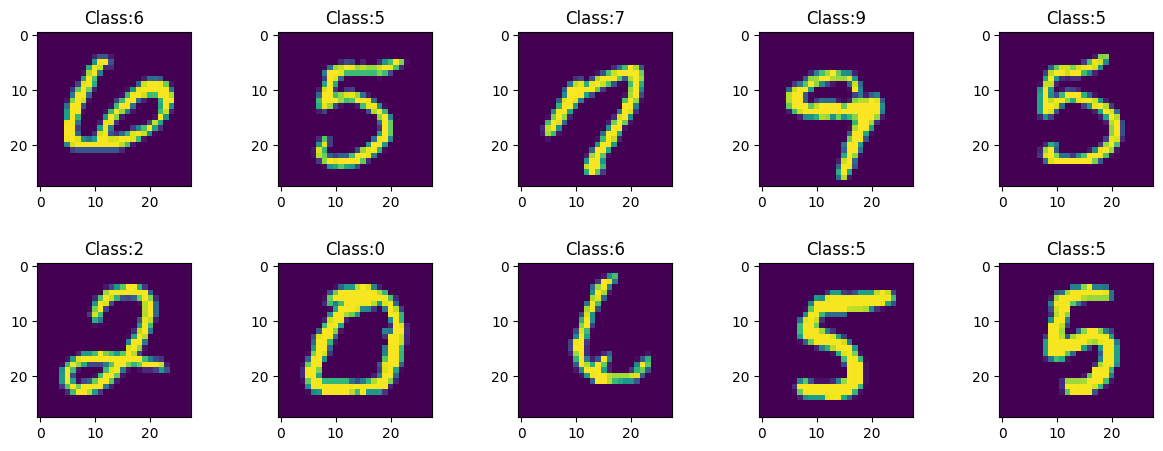

In [4]:
#Data visualization
fig, axes = plt.subplots(nrows=2, ncols=5,figsize=(15, 5))
ax = axes.ravel()
for i in range(10):
  ax[i].imshow(X_train[i].reshape(28, 28))
  ax[i].title.set_text('Class:'+str(y_train[i]))
plt.subplots_adjust(hspace=0.5)
plt.show()

In [5]:
y_train = keras. utils.to_categorical(y_train, num_classes)
y_test = keras.utils. to_categorical(y_test, num_classes)

In [6]:
model = Sequential()
model.add(Input(shape=input_shape))
model.add(Conv2D(32, kernel_size=(3,3), activation='relu'))
model.add(MaxPool2D(pool_size=(2,2)))
model.add(Conv2D(64, kernel_size=(3,3), activation='relu'))
model.add(MaxPool2D(pool_size=(2,2)))
model.add(Flatten())
model.add(Dense(units=10, activation='softmax'))
model. summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │        16,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 34,826 (136.04 KB)

 Trainable params: 34,826 (136.04 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy' ])
model_fit = model.fit(X_train, y_train, batch_size=128, epochs=15, validation_split=0.1, verbose=1)

Epoch 1/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 14s 87ms/step - accuracy: 0.8373 - loss: 0.5732 - val_accuracy: 0.9330 - val_loss: 0.2208
Epoch 2/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 19s 81ms/step - accuracy: 0.9547 - loss: 0.1487 - val_accuracy: 0.9630 - val_loss: 0.1270
Epoch 3/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 21s 87ms/step - accuracy: 0.9690 - loss: 0.0991 - val_accuracy: 0.9700 - val_loss: 0.1101
Epoch 4/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 23s 105ms/step - accuracy: 0.9769 - loss: 0.0754 - val_accuracy: 0.9700 - val_loss: 0.0923
Epoch 5/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 13s 92ms/step - accuracy: 0.9810 - loss: 0.0624 - val_accuracy: 0.9725 - val_loss: 0.0860
Epoch 6/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 12s 88ms/step - accuracy: 0.9833 - loss: 0.0519 - val_accuracy: 0.9765 - val_loss: 0.0804
Epoch 7/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 12s 88ms/step - accuracy: 0.9854 - loss: 0.0444 - val_accuracy: 0.9725 - val_loss: 0.0849
Epoch 8/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 19s 79ms/step - accuracy: 0.9868 - loss: 0.0403 -

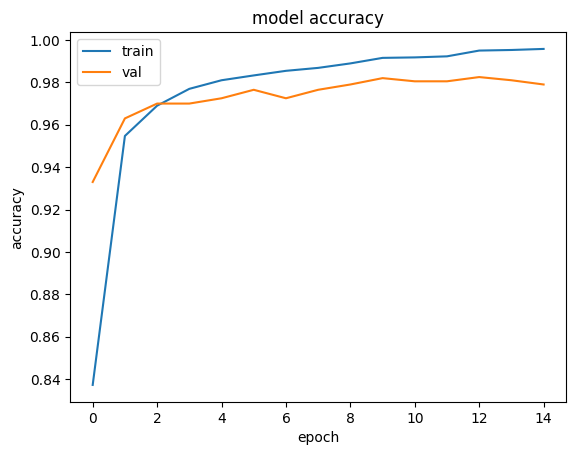

In [8]:
plt.plot(model_fit.history['accuracy' ])
plt.plot(model_fit.history['val_accuracy' ])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt. legend(['train', 'val'], loc='upper left')
plt.show()

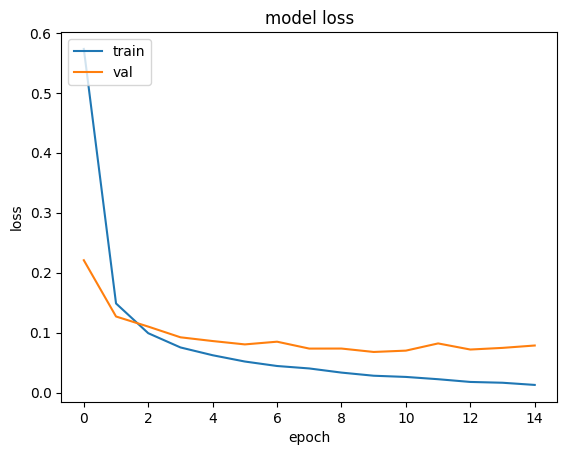

In [9]:
plt.plot(model_fit.history['loss'])
plt.plot(model_fit.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

In [10]:
score = model.evaluate(X_test, y_test, verbose=2)
print('Test loss:', score[0])
print('Test accuracy:', score[1])

313/313 - 2s - 7ms/step - accuracy: 0.9825 - loss: 0.0592
Test loss: 0.05918455123901367
Test accuracy: 0.9825000166893005


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
[[2.2571924e-14 1.5340040e-11 1.8325392e-09 9.9656439e-10 4.4959802e-18
  2.8719116e-14 1.0403386e-24 1.0000000e+00 9.0906501e-12 4.8192055e-11]]
7 7


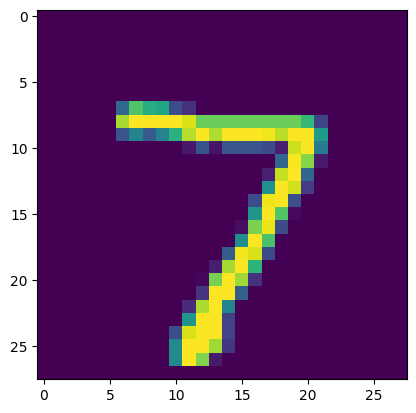

In [11]:
predict = model.predict(X_test[:1])
print(predict)
print(np.argmax(predict), np.argmax(y_test[0]))
plt.imshow(X_test[:1].reshape(28, 28))
plt.show()

In [12]:
model.save("cnn.keras")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
[[1.4964242e-05 5.1638108e-02 9.4834602e-01 3.8339003e-09 2.4400988e-18
  1.2513000e-13 8.8224505e-07 1.4428640e-16 7.0146111e-09 3.4186486e-20]]
2 2


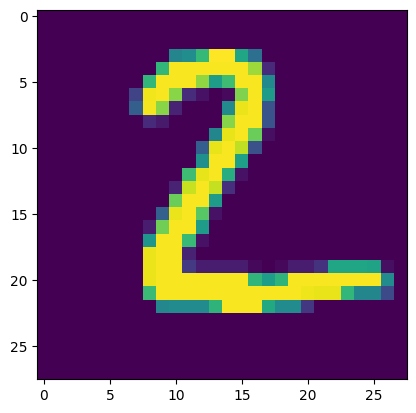

In [13]:
model = Sequential()
model.add(Input(shape=input_shape))
model.add(Conv2D(32, kernel_size=(3,3), activation='relu'))
model.add(MaxPool2D(pool_size=(2,2)))
model.add(Conv2D(64, kernel_size=(3,3), activation='relu'))
model.add(MaxPool2D(pool_size=(2,2)))
model.add(Flatten())
model.add(Dense(units=10, activation='softmax'))
model.load_weights('cnn.keras')

predict = model.predict(X_test[1:2])
print(predict)
print(np.argmax(predict), np.argmax(y_test[1]))
plt.imshow(X_test[1:2].reshape(28, 28))
plt.show()

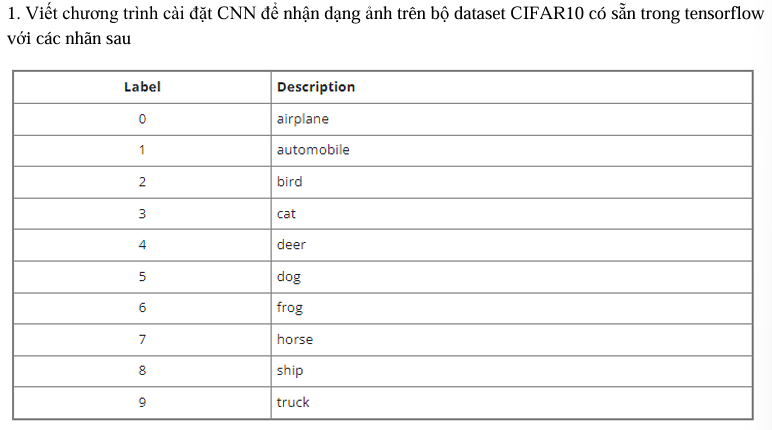

In [14]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

SEED = 42
tf.keras.utils.set_random_seed(SEED)

print("TensorFlow version:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))

TensorFlow version: 2.20.0
GPU: []


In [15]:
# Load CIFAR-10 có sẵn trong TensorFlow/Keras
(X_train_full, y_train_full), (X_test, y_test) = tf.keras.datasets.cifar10.load_data()

# Tên các lớp
class_names = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
]

print("X_train_full:", X_train_full.shape)
print("y_train_full:", y_train_full.shape)
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
X_train_full: (50000, 32, 32, 3)
y_train_full: (50000, 1)
X_test: (10000, 32, 32, 3)
y_test: (10000, 1)


In [16]:
# Chuyển label từ shape (N, 1) thành (N,)
y_train_full = y_train_full.reshape(-1)
y_test = y_test.reshape(-1)

# Chuẩn hóa pixel từ [0, 255] về [0, 1]
X_train_full = X_train_full.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

# Chia train thành train/validation
# 45,000 ảnh train, 5,000 ảnh validation
X_train = X_train_full[:45000]
y_train = y_train_full[:45000]

X_val = X_train_full[45000:]
y_val = y_train_full[45000:]

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_val:", X_val.shape)
print("y_val:", y_val.shape)
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: (45000, 32, 32, 3)
y_train: (45000,)
X_val: (5000, 32, 32, 3)
y_val: (5000,)
X_test: (10000, 32, 32, 3)
y_test: (10000,)


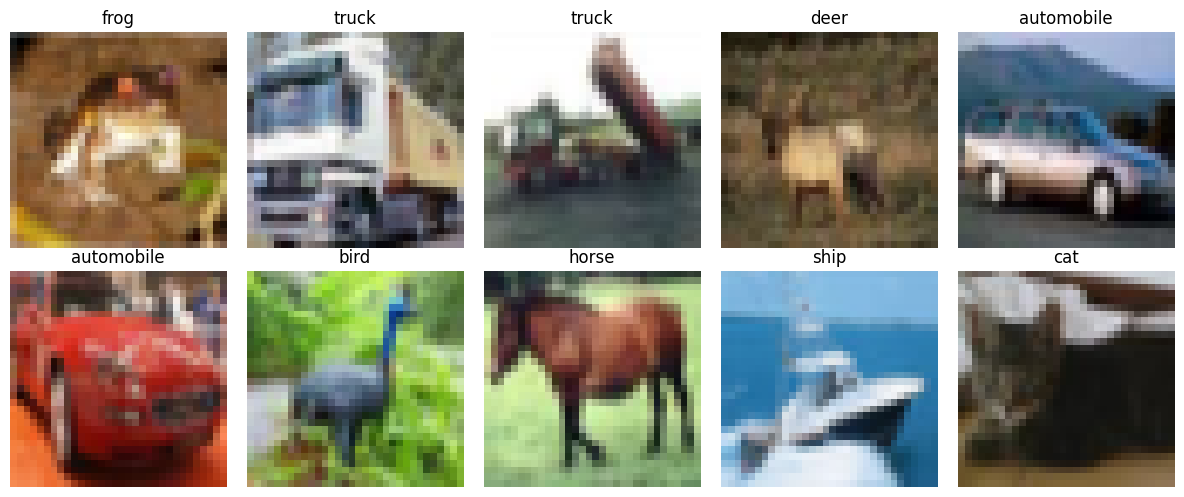

In [17]:
plt.figure(figsize=(12, 5))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_train[i])
    plt.title(class_names[y_train[i]])
    plt.axis("off")

plt.tight_layout()
plt.show()

In [18]:
BATCH_SIZE = 64
AUTOTUNE = tf.data.AUTOTUNE

train_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train))
val_ds = tf.data.Dataset.from_tensor_slices((X_val, y_val))
test_ds = tf.data.Dataset.from_tensor_slices((X_test, y_test))

train_ds = (
    train_ds
    .shuffle(buffer_size=10000, seed=SEED)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

val_ds = (
    val_ds
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

test_ds = (
    test_ds
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

In [19]:
num_classes = 10
input_shape = (32, 32, 3)

weight_decay = 1e-4

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.08),
    layers.RandomZoom(0.10),
    layers.RandomTranslation(0.08, 0.08),
], name="data_augmentation")


def build_cifar10_cnn():
    inputs = layers.Input(shape=input_shape)

    # Data augmentation chỉ hoạt động khi training=True
    x = data_augmentation(inputs)

    # Block 1
    x = layers.Conv2D(
        32, (3, 3),
        padding="same",
        kernel_regularizer=regularizers.l2(weight_decay)
    )(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    x = layers.Conv2D(
        32, (3, 3),
        padding="same",
        kernel_regularizer=regularizers.l2(weight_decay)
    )(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    x = layers.MaxPooling2D(pool_size=(2, 2))(x)
    x = layers.Dropout(0.25)(x)

    # Block 2
    x = layers.Conv2D(
        64, (3, 3),
        padding="same",
        kernel_regularizer=regularizers.l2(weight_decay)
    )(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    x = layers.Conv2D(
        64, (3, 3),
        padding="same",
        kernel_regularizer=regularizers.l2(weight_decay)
    )(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    x = layers.MaxPooling2D(pool_size=(2, 2))(x)
    x = layers.Dropout(0.30)(x)

    # Block 3
    x = layers.Conv2D(
        128, (3, 3),
        padding="same",
        kernel_regularizer=regularizers.l2(weight_decay)
    )(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    x = layers.Conv2D(
        128, (3, 3),
        padding="same",
        kernel_regularizer=regularizers.l2(weight_decay)
    )(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    x = layers.MaxPooling2D(pool_size=(2, 2))(x)
    x = layers.Dropout(0.35)(x)

    # Classification head
    x = layers.GlobalAveragePooling2D()(x)

    x = layers.Dense(
        128,
        activation="relu",
        kernel_regularizer=regularizers.l2(weight_decay)
    )(x)
    x = layers.Dropout(0.40)(x)

    outputs = layers.Dense(num_classes, activation="softmax")(x)

    model = models.Model(inputs, outputs, name="CIFAR10_CNN")
    return model


model = build_cifar10_cnn()
model.summary()

Model: "CIFAR10_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_2 (ReLU)                  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_3 (ReLU)                  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_4 (ReLU)                  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 306,602 (1.17 MB)

 Trainable params: 305,706 (1.17 MB)

 Non-trainable params: 896 (3.50 KB)

In [20]:
loss="sparse_categorical_crossentropy"

In [21]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
callbacks = [
    ModelCheckpoint(
        filepath="best_cifar10_cnn.keras",
        monitor="val_accuracy",
        save_best_only=True,
        mode="max",
        verbose=1
    ),
    EarlyStopping(
        monitor="val_accuracy",
        patience=10,
        restore_best_weights=True,
        mode="max",
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=4,
        min_lr=1e-6,
        verbose=1
    )
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=callbacks
)

Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 0s 515ms/step - accuracy: 0.3081 - loss: 1.9206
Epoch 1: val_accuracy improved from None to 0.44220, saving model to best_cifar10_cnn.keras

Epoch 1: finished saving model to best_cifar10_cnn.keras
704/704 ━━━━━━━━━━━━━━━━━━━━ 382s 529ms/step - accuracy: 0.3756 - loss: 1.7380 - val_accuracy: 0.4422 - val_loss: 1.5445 - learning_rate: 0.0010
Epoch 2/20
158/704 ━━━━━━━━━━━━━━━━━━━━ 4:39 511ms/step - accuracy: 0.4612 - loss: 1.5210

In [ ]:
plt.figure(figsize=(12, 5))

# Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.grid(True)

# Loss
plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
test_loss, test_acc = model.evaluate(test_ds)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_acc)

In [ ]:
y_pred_prob = model.predict(test_ds)
y_pred = np.argmax(y_pred_prob, axis=1)

print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=class_names))

In [ ]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("CIFAR-10 Confusion Matrix")
plt.show()

In [ ]:
plt.figure(figsize=(14, 8))

for i in range(20):
    plt.subplot(4, 5, i + 1)

    img = X_test[i]
    true_label = y_test[i]
    pred_label = y_pred[i]
    confidence = np.max(y_pred_prob[i])

    plt.imshow(img)

    title = f"True: {class_names[true_label]}\nPred: {class_names[pred_label]}\nConf: {confidence:.2f}"

    if true_label == pred_label:
        color = "green"
    else:
        color = "red"

    plt.title(title, color=color, fontsize=9)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
model.save("cifar10_cnn.keras")
print("Đã lưu mô hình: cifar10_cnn.keras")

In [ ]:
loaded_model = tf.keras.models.load_model("cifar10_cnn.keras", compile=False)

loaded_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

loaded_model.evaluate(test_ds)

2. Hãy viết chương trình cài đặt CNN để nhận dạng ảnh Cat hoặc Dog. Dữ liệu do giảng viên cung cấp

In [ ]:
import os
import random
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)

print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))

In [ ]:
DATA_ROOT = Path("/content/dataset")   # SỬA ĐƯỜNG DẪN Ở ĐÂY

IMG_SIZE = (150, 150)
BATCH_SIZE = 32
NUM_CLASSES = 2

print("DATA_ROOT:", DATA_ROOT)
print("Exists:", DATA_ROOT.exists())

if DATA_ROOT.exists():
    print("Subfolders:", os.listdir(DATA_ROOT))

In [ ]:
from pathlib import Path
import os

# Nếu Kaggle Notebook chưa có kagglehub thì cài
try:
    import kagglehub
except ImportError:
    !pip install -q kagglehub
    import kagglehub


# =========================
# DATASET KAGGLE PUBLIC
# =========================

DATASET_HANDLE = "samuelcortinhas/cats-and-dogs-image-classification"

DATA_ROOT = Path(
    kagglehub.dataset_download(DATASET_HANDLE)
)

IMG_SIZE = (150, 150)
BATCH_SIZE = 32
NUM_CLASSES = 2

print("DATASET_HANDLE:", DATASET_HANDLE)
print("DATA_ROOT:", DATA_ROOT)
print("Exists:", DATA_ROOT.exists())

if DATA_ROOT.exists():
    print("Nội dung DATA_ROOT:")
    for item in os.listdir(DATA_ROOT):
        print("-", item)
else:
    raise FileNotFoundError("Không tải/gắn được dataset từ Kaggle.")

In [ ]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_ROOT,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int"
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_ROOT,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int"
)

class_names = train_ds.class_names

print("Class names:", class_names)
print("Number of classes:", len(class_names))

In [ ]:
plt.figure(figsize=(10, 6))

for images, labels in train_ds.take(1):
    for i in range(9):
        plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i].numpy()])
        plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
AUTOTUNE = tf.data.AUTOTUNE

normalization_layer = layers.Rescaling(1.0 / 255)

train_ds = train_ds.map(
    lambda images, labels: (normalization_layer(images), labels),
    num_parallel_calls=AUTOTUNE
)

val_ds = val_ds.map(
    lambda images, labels: (normalization_layer(images), labels),
    num_parallel_calls=AUTOTUNE
)

train_ds = train_ds.cache().shuffle(1000, seed=SEED).prefetch(AUTOTUNE)
val_ds = val_ds.cache().prefetch(AUTOTUNE)

for images, labels in train_ds.take(1):
    print("Image batch shape:", images.shape)
    print("Label batch shape:", labels.shape)
    print("Pixel min:", tf.reduce_min(images).numpy())
    print("Pixel max:", tf.reduce_max(images).numpy())

In [ ]:
weight_decay = 1e-4

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.05),
], name="data_augmentation")


def build_cat_dog_cnn(input_shape=(150, 150, 3)):
    inputs = layers.Input(shape=input_shape)

    # Data augmentation chỉ hoạt động khi training
    x = data_augmentation(inputs)

    # Block 1
    x = layers.Conv2D(
        32,
        kernel_size=(3, 3),
        padding="same",
        kernel_regularizer=regularizers.l2(weight_decay)
    )(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.MaxPooling2D(pool_size=(2, 2))(x)

    # Block 2
    x = layers.Conv2D(
        64,
        kernel_size=(3, 3),
        padding="same",
        kernel_regularizer=regularizers.l2(weight_decay)
    )(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.MaxPooling2D(pool_size=(2, 2))(x)

    # Block 3
    x = layers.Conv2D(
        128,
        kernel_size=(3, 3),
        padding="same",
        kernel_regularizer=regularizers.l2(weight_decay)
    )(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.MaxPooling2D(pool_size=(2, 2))(x)

    # Block 4
    x = layers.Conv2D(
        256,
        kernel_size=(3, 3),
        padding="same",
        kernel_regularizer=regularizers.l2(weight_decay)
    )(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.MaxPooling2D(pool_size=(2, 2))(x)

    # Classification head
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dropout(0.35)(x)

    # Binary classification: Cat / Dog
    outputs = layers.Dense(1, activation="sigmoid")(x)

    model = models.Model(inputs=inputs, outputs=outputs, name="CatDog_CNN")
    return model


model = build_cat_dog_cnn(input_shape=(150, 150, 3))
model.summary()

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
Dense(1, activation="sigmoid")
loss="binary_crossentropy"

In [ ]:
callbacks = [
    ModelCheckpoint(
        filepath="best_cat_dog_cnn.keras",
        monitor="val_accuracy",
        save_best_only=True,
        mode="max",
        verbose=1
    ),
    EarlyStopping(
        monitor="val_accuracy",
        patience=8,
        restore_best_weights=True,
        mode="max",
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=3,
        min_lr=1e-6,
        verbose=1
    )
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    callbacks=callbacks
)

In [ ]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
y_true = []
y_pred = []
y_prob = []

for images, labels in val_ds:
    probs = model.predict(images, verbose=0).reshape(-1)
    preds = (probs >= 0.5).astype("int32")

    y_true.extend(labels.numpy())
    y_pred.extend(preds)
    y_prob.extend(probs)

y_true = np.array(y_true)
y_pred = np.array(y_pred)
y_prob = np.array(y_prob)

print("y_true shape:", y_true.shape)
print("y_pred shape:", y_pred.shape)

In [ ]:
print(classification_report(
    y_true,
    y_pred,
    target_names=class_names
))

In [ ]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Cat/Dog CNN")
plt.show()

In [ ]:
from tensorflow.keras.utils import load_img, img_to_array

def predict_cat_dog(image_path, model, class_names, img_size=(150, 150)):
    img = load_img(image_path, target_size=img_size)
    img_array = img_to_array(img)
    img_array = img_array.astype("float32") / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    prob_class_1 = model.predict(img_array, verbose=0)[0][0]

    pred_id = 1 if prob_class_1 >= 0.5 else 0
    pred_class = class_names[pred_id]

    confidence = prob_class_1 if pred_id == 1 else 1.0 - prob_class_1

    plt.imshow(img)
    plt.axis("off")
    plt.title(f"Prediction: {pred_class} | Confidence: {confidence:.4f}")
    plt.show()

    return pred_class, confidence

In [ ]:
model.save("cat_dog_cnn.keras")
print("Đã lưu mô hình: cat_dog_cnn.keras")

In [ ]:
loaded_model = tf.keras.models.load_model("cat_dog_cnn.keras", compile=False)

loaded_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

loaded_model.evaluate(val_ds)

3. Hãy viết chương trình cài đặt CNN để nhận dạng ảnh Fashion-MNIST. Dữ liệu do giảng viên cung
cấp.

In [ ]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

SEED = 42
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)

print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))

In [ ]:
import tensorflow as tf
import numpy as np

# =========================
# LẤY DATASET BẰNG API KERAS
# Không dùng /kaggle/input
# Không dùng file CSV
# =========================

fashion_mnist = tf.keras.datasets.fashion_mnist

(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

IMG_SIZE = (28, 28)
BATCH_SIZE = 32
NUM_CLASSES = 10

class_names = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot"
]

print("x_train:", x_train.shape)
print("y_train:", y_train.shape)
print("x_test :", x_test.shape)
print("y_test :", y_test.shape)

print("Số lớp:", NUM_CLASSES)
print("Tên lớp:", class_names)

In [ ]:
import tensorflow as tf
import numpy as np
import pandas as pd

# =========================
# LẤY FASHION-MNIST BẰNG API
# Không dùng /kaggle/input
# Không đọc file CSV
# =========================

(x_train, y_train), (x_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()

IMG_SIZE = (28, 28)
BATCH_SIZE = 32
NUM_CLASSES = 10

class_names = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot"
]

print("x_train:", x_train.shape)
print("y_train:", y_train.shape)
print("x_test :", x_test.shape)
print("y_test :", y_test.shape)
print("Classes:", class_names)

In [ ]:
X_train_full = df_train.iloc[:, 1:].values
y_train_full = df_train.iloc[:, 0].values

X_test = df_test.iloc[:, 1:].values
y_test = df_test.iloc[:, 0].values

print("X_train_full:", X_train_full.shape)
print("y_train_full:", y_train_full.shape)
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

In [ ]:
X_train_full = X_train_full.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

X_train_full = X_train_full.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

print("X_train_full:", X_train_full.shape)
print("X_test:", X_test.shape)

In [ ]:
X_train = X_train_full[:54000]
y_train = y_train_full[:54000]

X_val = X_train_full[54000:]
y_val = y_train_full[54000:]

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("X_val:", X_val.shape)
print("y_val:", y_val.shape)

print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

In [ ]:
class_names = [
    "T-shirt/top",  # 0
    "Trouser",      # 1
    "Pullover",     # 2
    "Dress",        # 3
    "Coat",         # 4
    "Sandal",       # 5
    "Shirt",        # 6
    "Sneaker",      # 7
    "Bag",          # 8
    "Ankle boot"    # 9
]

num_classes = 10
input_shape = (28, 28, 1)

print("Number of classes:", num_classes)
print("Input shape:", input_shape)

In [ ]:
plt.figure(figsize=(12, 6))

for i in range(15):
    plt.subplot(3, 5, i + 1)
    plt.imshow(X_train[i].reshape(28, 28), cmap="gray")
    plt.title(class_names[y_train[i]])
    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
BATCH_SIZE = 64
AUTOTUNE = tf.data.AUTOTUNE

train_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train))
val_ds = tf.data.Dataset.from_tensor_slices((X_val, y_val))
test_ds = tf.data.Dataset.from_tensor_slices((X_test, y_test))

train_ds = (
    train_ds
    .shuffle(buffer_size=10000, seed=SEED)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

val_ds = (
    val_ds
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

test_ds = (
    test_ds
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

In [ ]:
weight_decay = 1e-4

def build_fashion_mnist_cnn(input_shape=(28, 28, 1), num_classes=10):
    inputs = layers.Input(shape=input_shape)

    # Block 1
    x = layers.Conv2D(
        32,
        kernel_size=(3, 3),
        padding="same",
        kernel_regularizer=regularizers.l2(weight_decay)
    )(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    x = layers.Conv2D(
        32,
        kernel_size=(3, 3),
        padding="same",
        kernel_regularizer=regularizers.l2(weight_decay)
    )(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    x = layers.MaxPooling2D(pool_size=(2, 2))(x)
    x = layers.Dropout(0.25)(x)

    # Block 2
    x = layers.Conv2D(
        64,
        kernel_size=(3, 3),
        padding="same",
        kernel_regularizer=regularizers.l2(weight_decay)
    )(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    x = layers.Conv2D(
        64,
        kernel_size=(3, 3),
        padding="same",
        kernel_regularizer=regularizers.l2(weight_decay)
    )(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    x = layers.MaxPooling2D(pool_size=(2, 2))(x)
    x = layers.Dropout(0.30)(x)

    # Block 3
    x = layers.Conv2D(
        128,
        kernel_size=(3, 3),
        padding="same",
        kernel_regularizer=regularizers.l2(weight_decay)
    )(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    x = layers.GlobalAveragePooling2D()(x)

    # Classification head
    x = layers.Dense(
        128,
        activation="relu",
        kernel_regularizer=regularizers.l2(weight_decay)
    )(x)
    x = layers.Dropout(0.40)(x)

    outputs = layers.Dense(num_classes, activation="softmax")(x)

    model = models.Model(inputs=inputs, outputs=outputs, name="FashionMNIST_CNN")
    return model


model = build_fashion_mnist_cnn(input_shape=input_shape, num_classes=num_classes)
model.summary()

In [ ]:
loss="sparse_categorical_crossentropy"

In [ ]:
import tensorflow as tf
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

# =========================
# COMPILE MODEL TRƯỚC KHI FIT
# =========================

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"]
)

callbacks = [
    ModelCheckpoint(
        filepath="best_fashion_mnist_cnn.keras",
        monitor="val_accuracy",
        save_best_only=True,
        mode="max",
        verbose=1
    ),
    EarlyStopping(
        monitor="val_accuracy",
        patience=8,
        restore_best_weights=True,
        mode="max",
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=3,
        min_lr=1e-6,
        verbose=1
    )
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    callbacks=callbacks
)

In [ ]:
test_loss, test_acc = model.evaluate(test_ds)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_acc)

In [ ]:
y_pred_prob = model.predict(test_ds)
y_pred = np.argmax(y_pred_prob, axis=1)

print(classification_report(
    y_test,
    y_pred,
    target_names=class_names
))

In [ ]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Fashion-MNIST Confusion Matrix")
plt.show()

In [ ]:
plt.figure(figsize=(14, 8))

for i in range(20):
    plt.subplot(4, 5, i + 1)

    img = X_test[i].reshape(28, 28)
    true_label = y_test[i]
    pred_label = y_pred[i]
    confidence = np.max(y_pred_prob[i])

    plt.imshow(img, cmap="gray")

    title = (
        f"True: {class_names[true_label]}\n"
        f"Pred: {class_names[pred_label]}\n"
        f"Conf: {confidence:.2f}"
    )

    color = "green" if true_label == pred_label else "red"

    plt.title(title, color=color, fontsize=9)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
model.save("fashion_mnist_cnn.keras")
print("Đã lưu mô hình: fashion_mnist_cnn.keras")

In [ ]:
loaded_model = tf.keras.models.load_model("fashion_mnist_cnn.keras", compile=False)

loaded_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

loaded_model.evaluate(test_ds)